# Analyse — Évaluation et tuning d'un système RAG

Ce notebook analyse les résultats du balayage d'hyperparamètres (`results/results.csv`)
produit par `scripts/run_eval.py`.

**Question de recherche :** quelle configuration (taille de chunk, overlap, `top_k`,
méthode d'embedding) maximise la qualité du *retrieval* sur notre base de connaissances
métier de 10 documents et notre jeu de 20 questions ?

**Métriques** (toutes indépendantes du LLM, donc reproductibles sans GPU) :
- `hit@k` — le bon document est-il dans les `top_k` chunks récupérés ?
- `MRR` — rang moyen inverse du premier bon chunk (récompense un bon classement).
- `span_recall@k` — l'extrait de réponse attendu est-il présent dans les chunks récupérés ?
- `precision@k` — proportion des chunks récupérés issus du bon document.


In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "../src")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../results/results.csv")
print(f"{len(df)} configurations evaluees sur {df['n_questions'].iloc[0]} questions")
df.head()

88 configurations evaluees sur 20 questions


,embedding,chunk_size,chunk_overlap,top_k,n_chunks,hit_at_k,mrr,span_recall_at_k,precision_at_k,n_questions
0,tfidf,40,0,1,58,0.95,0.9500,0.90,0.9500,20
1,hashing,40,0,1,58,0.55,0.5500,0.55,0.5500,20
2,tfidf,40,0,3,58,1.00,0.9750,0.95,0.6333,20
3,hashing,40,0,3,58,0.90,0.7083,0.75,0.4000,20
4,tfidf,40,0,5,58,1.00,0.9750,0.95,0.4900,20


## 1. Vue d'ensemble

On regarde d'abord la distribution des scores : y a-t-il vraiment de la variance à exploiter ?

In [2]:
df[["hit_at_k","mrr","span_recall_at_k","precision_at_k"]].describe().round(3)

,hit_at_k,mrr,span_recall_at_k,precision_at_k
count,88.000,88.000,88.000,88.000
mean,0.946,0.897,0.920,0.491
std,0.079,0.086,0.091,0.264
min,0.550,0.550,0.550,0.130
25%,0.950,0.842,0.900,0.268
50%,0.950,0.913,0.950,0.418
75%,1.000,0.967,1.000,0.750
max,1.000,1.000,1.000,1.000


## 2. Effet de la méthode d'embedding

TF-IDF (vocabulaire appris sur le corpus) vs Hashing (sans vocabulaire, *stateless*).

In [3]:
emb = df.groupby("embedding")[["hit_at_k","mrr","span_recall_at_k","precision_at_k"]].mean().round(3)
display(emb)
print("Gain relatif MRR de tfidf vs hashing : "
      f"{(emb.loc['tfidf','mrr']/emb.loc['hashing','mrr']-1)*100:.1f} %")

,hit_at_k,mrr,span_recall_at_k,precision_at_k
embedding,,,,
hashing,0.906,0.830,0.870,0.433
tfidf,0.986,0.964,0.969,0.549


Gain relatif MRR de tfidf vs hashing : 16.1 %


**Lecture.** TF-IDF domine hashing sur toutes les métriques. Le hashing perd de
l'information par collisions de hachage et n'a pas de pondération IDF pour valoriser
les termes discriminants (chiffres, mots-clés métier) — précisément ceux qui portent
la réponse dans nos questions factuelles.

## 3. Compromis precision / rappel selon `top_k`

In [4]:
t = df[df.embedding=="tfidf"].groupby("top_k")[["hit_at_k","mrr","precision_at_k"]].mean().round(3)
display(t)

,hit_at_k,mrr,precision_at_k
top_k,,,
1,0.945,0.945,0.945
3,1.000,0.970,0.586
5,1.000,0.970,0.414
10,1.000,0.970,0.249


**Lecture.** Augmenter `top_k` fait grimper le rappel (`hit@k` atteint 1.0 dès k=3)
mais effondre la `precision@k` : à k=10, on noie le bon chunk dans du bruit. Pour un RAG,
plus de contexte n'est pas gratuit : cela dilue le prompt du LLM et augmente le coût.
Un `top_k` de 3 capture tout le rappel utile en gardant une précision correcte.

## 4. Effet de la taille de chunk

In [5]:
c = (df[(df.embedding=="tfidf") & (df.top_k>=3)]
      .groupby("chunk_size")[["mrr","span_recall_at_k"]].mean().round(3))
display(c)

,mrr,span_recall_at_k
chunk_size,,
40,0.971,0.975
80,0.992,0.983
120,0.972,1.000
200,0.944,1.000


**Lecture.** Deux forces opposées :
- des chunks **trop petits** fragmentent la réponse → `span_recall` plus faible ;
- des chunks **trop grands** diluent le signal → chaque chunk est moins spécifique, le
  MRR baisse (le bon passage est noyé dans du texte hors-sujet).

Le compromis se situe autour de **80–120 mots** ici.

## 5. Interaction chunk_size × overlap (heatmap)

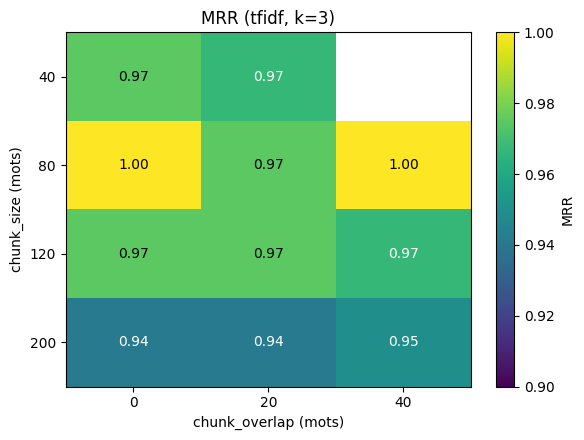

In [6]:
import numpy as np
piv = (df[(df.embedding=="tfidf") & (df.top_k==3)]
       .pivot_table(index="chunk_size", columns="chunk_overlap", values="mrr"))
fig, ax = plt.subplots(figsize=(6,4.5))
im = ax.imshow(piv.values, cmap="viridis", vmin=0.9, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
ax.set_xlabel("chunk_overlap (mots)"); ax.set_ylabel("chunk_size (mots)")
ax.set_title("MRR (tfidf, k=3)")
for i in range(len(piv.index)):
    for j in range(len(piv.columns)):
        v = piv.values[i,j]
        if not np.isnan(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",
                    color="white" if v<0.97 else "black")
fig.colorbar(im, ax=ax, label="MRR"); plt.tight_layout(); plt.show()

**Lecture.** Un léger overlap aide (il évite de couper une réponse au milieu de deux
chunks), mais l'effet reste secondaire par rapport à la taille de chunk et au choix
d'embedding. Au-delà d'un certain point, l'overlap ne fait qu'augmenter le nombre de
chunks (donc le coût d'indexation) sans gain de qualité.

## 6. Meilleure configuration

On cherche la config qui maximise d'abord `span_recall@k`, puis le MRR, puis la précision.

In [7]:
best = df.sort_values(["span_recall_at_k","mrr","precision_at_k"], ascending=False).head(5)
display(best.reset_index(drop=True))
top = best.iloc[0]
print("\nConfiguration retenue :")
print(f"  embedding      = {top.embedding}")
print(f"  chunk_size     = {int(top.chunk_size)} mots")
print(f"  chunk_overlap  = {int(top.chunk_overlap)} mots")
print(f"  top_k          = {int(top.top_k)}")
print(f"  -> hit@k={top.hit_at_k}  MRR={top.mrr}  "
      f"span_recall@k={top.span_recall_at_k}  precision@k={top.precision_at_k}")

,embedding,chunk_size,chunk_overlap,top_k,n_chunks,hit_at_k,mrr,span_recall_at_k,precision_at_k,n_questions
0,tfidf,80,40,1,48,1.0,1.000,1.0,1.0000,20
1,tfidf,80,40,3,48,1.0,1.000,1.0,0.7500,20
2,tfidf,80,40,5,48,1.0,1.000,1.0,0.5900,20
3,tfidf,80,40,10,48,1.0,1.000,1.0,0.3450,20
4,tfidf,80,20,3,38,1.0,0.975,1.0,0.7167,20



Configuration retenue :
  embedding      = tfidf
  chunk_size     = 80 mots
  chunk_overlap  = 40 mots
  top_k          = 1
  -> hit@k=1.0  MRR=1.0  span_recall@k=1.0  precision@k=1.0


## 7. Conclusions

1. **Le choix d'embedding est le levier n°1** : TF-IDF > hashing sur toutes les métriques.
   Prochaine étape naturelle : comparer un embedding **sémantique** (sentence-transformers
   ou `nomic-embed-text` via Ollama) pour gérer les reformulations que TF-IDF (lexical) rate.
2. **`top_k` = 3** capte tout le rappel utile sans effondrer la précision ni gonfler le
   prompt du LLM.
3. **Taille de chunk ~80–120 mots** : compromis entre couverture de la réponse
   (`span_recall`) et spécificité du chunk (MRR).
4. **L'overlap** apporte un gain marginal ; inutile de le pousser au-delà de ~20–40 mots.

> **Limite honnête.** L'évaluation ci-dessus porte sur le *retrieval* (indépendant du LLM).
> La qualité de **génération** (fidélité, pertinence façon RAGAS) nécessite un LLM juge :
> le code est fourni dans `ragkit.metrics.ragas_evaluate` et s'active avec Ollama
> (voir le README). C'est l'extension suivante du projet.